# Online Retail: Data Cleaning & EDA

Customer analysis on the UCI Online Retail dataset using SQL (SQLite) and Python.

**Steps:** data cleaning, revenue overview, RFM segmentation, churn, cohort retention, CLV, market basket.

In [1]:
import os
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import squarify

sns.set_theme(style='white')

## 1. Load Data

In [2]:
df_raw = pd.read_csv('../data/raw/Online_Retail.csv', encoding='ISO-8859-1')
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])

conn = sqlite3.connect('../data/retail.db')
df_raw.to_sql('raw_retail', conn, if_exists='replace', index=False)

def run(sql):
    return pd.read_sql_query(sql, conn)

def save(name):
    os.makedirs('../assets', exist_ok=True)
    plt.tight_layout()
    plt.savefig(f'../assets/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

def barh(df, x, y, title, xlabel, palette, name, labels=None, size=(10, 5)):
    plt.figure(figsize=size)
    ax = sns.barplot(data=df, x=x, y=y, hue=y, palette=palette, legend=False)
    if labels is not None:
        for i, text in enumerate(labels):
            ax.text(df[x].iloc[i], i, f' {text}', va='center')
        ax.set_xlim(0, df[x].max() * 1.25)
    ax.set(title=title, xlabel=xlabel, ylabel='')
    sns.despine()
    save(name)

print('Rows loaded:', len(df_raw))
df_raw.head()

Rows loaded: 541909


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Clean Data

Check missing IDs and invalid values, then build a clean table with `total_amount` and a cancellation flag.

In [3]:
run('''
SELECT
    COUNT(*) AS total_rows,
    COUNT(CASE WHEN CustomerID IS NULL THEN 1 END) AS missing_customer_id,
    COUNT(CASE WHEN Quantity <= 0 THEN 1 END) AS non_positive_quantity,
    COUNT(CASE WHEN UnitPrice <= 0 THEN 1 END) AS non_positive_price
FROM raw_retail;
''')

,total_rows,missing_customer_id,non_positive_quantity,non_positive_price
0,541909,135080,10624,2517


In [4]:
conn.executescript('''
DROP TABLE IF EXISTS clean_retail;

CREATE TABLE clean_retail AS
SELECT
    InvoiceNo,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country,
    Quantity * UnitPrice AS TotalAmount,
    CASE WHEN InvoiceNo LIKE 'C%' OR Quantity < 0 THEN 1 ELSE 0 END AS IsCancelled
FROM raw_retail
WHERE UnitPrice > 0;
''')
print('clean_retail is ready.')

clean_retail is ready.


## 3. Revenue Overview

In [5]:
run('''
SELECT
    ROUND(SUM(TotalAmount), 2) AS total_revenue,
    COUNT(DISTINCT CustomerID) AS unique_customers,
    COUNT(DISTINCT InvoiceNo) AS total_orders
FROM clean_retail
WHERE IsCancelled = 0;
''')

,total_revenue,unique_customers,total_orders
0,10666684.54,4338,19960


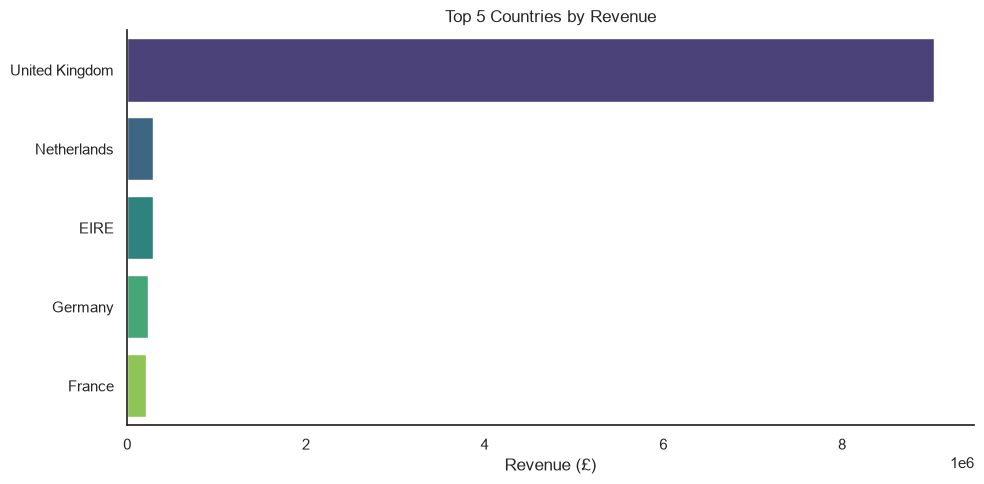

In [6]:
df_countries = run('''
SELECT
    Country,
    ROUND(SUM(TotalAmount), 2) AS total_revenue
FROM clean_retail
WHERE IsCancelled = 0
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 5;
''')

barh(df_countries, 'total_revenue', 'Country', 'Top 5 Countries by Revenue',
     'Revenue (£)', 'viridis', '01_top_countries')

## 4. RFM Segmentation

Recency, frequency and monetary value per customer, scored from 1 to 5 and grouped into segments.

In [7]:
df_rfm = run('''
SELECT
    CustomerID,
    ROUND(
        julianday((SELECT DATE(MAX(InvoiceDate), '+1 day') FROM clean_retail WHERE IsCancelled = 0))
        - julianday(MAX(InvoiceDate)), 0
    ) AS recency,
    COUNT(DISTINCT InvoiceNo) AS frequency,
    SUM(TotalAmount) AS monetary
FROM clean_retail
WHERE IsCancelled = 0 AND CustomerID IS NOT NULL
GROUP BY CustomerID;
''')

df_rfm['R_Score'] = pd.qcut(df_rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])
df_rfm['F_Score'] = pd.qcut(df_rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
df_rfm['M_Score'] = pd.qcut(df_rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5])
df_rfm['RFM_Score'] = df_rfm[['R_Score', 'F_Score', 'M_Score']].astype(str).agg(''.join, axis=1)
df_rfm.head()

,CustomerID,recency,frequency,monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326.0,1,77183.60,1,1,5,115
1,12347.0,2.0,7,4310.00,5,5,5,555
2,12348.0,75.0,4,1797.24,2,4,4,244
3,12349.0,19.0,1,1757.55,4,1,4,414
4,12350.0,310.0,1,334.40,1,1,2,112


In [8]:
def assign_segment(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions (VIP)'
    if m == 5 and f <= 3:
        return 'Big Spenders'
    if r >= 3 and f >= 4:
        return 'Loyal Customers'
    if r >= 4 and f in [2, 3]:
        return 'Potential Loyalists'
    if r >= 4 and f == 1:
        return 'Recent High-Value' if m >= 3 else 'New Customers'
    if r == 3 and f in [2, 3]:
        return 'Need Attention'
    if r <= 2 and (f >= 4 or m >= 4):
        return "Can't Lose Them"
    if r <= 2 and f in [2, 3]:
        return 'At Risk'
    return 'Hibernating / Lost'

df_rfm['Segment'] = df_rfm.apply(assign_segment, axis=1)

segment_summary = df_rfm.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('recency', 'mean'),
    Avg_Frequency=('frequency', 'mean'),
    Total_Monetary=('monetary', 'sum'),
    Avg_Monetary=('monetary', 'mean'),
).sort_values('Total_Monetary', ascending=False)

segment_summary

,Customer_Count,Avg_Recency,Avg_Frequency,Total_Monetary,Avg_Monetary
Segment,,,,,
Champions (VIP),948,12.397679,11.148734,5753707.430,6069.311635
Loyal Customers,513,37.968811,5.134503,951097.501,1853.991230
Can't Lose Them,409,145.210269,3.916870,611450.980,1494.990171
Big Spenders,74,93.648649,2.283784,579966.731,7837.388257
At Risk,740,200.009459,1.564865,278027.682,375.713084
Potential Loyalists,459,16.503268,1.995643,272972.050,594.710349
Hibernating / Lost,692,182.161850,1.000000,215096.410,310.832962
Need Attention,369,52.124661,1.783198,209054.030,566.542087
New Customers,116,17.827586,1.000000,27208.080,234.552414


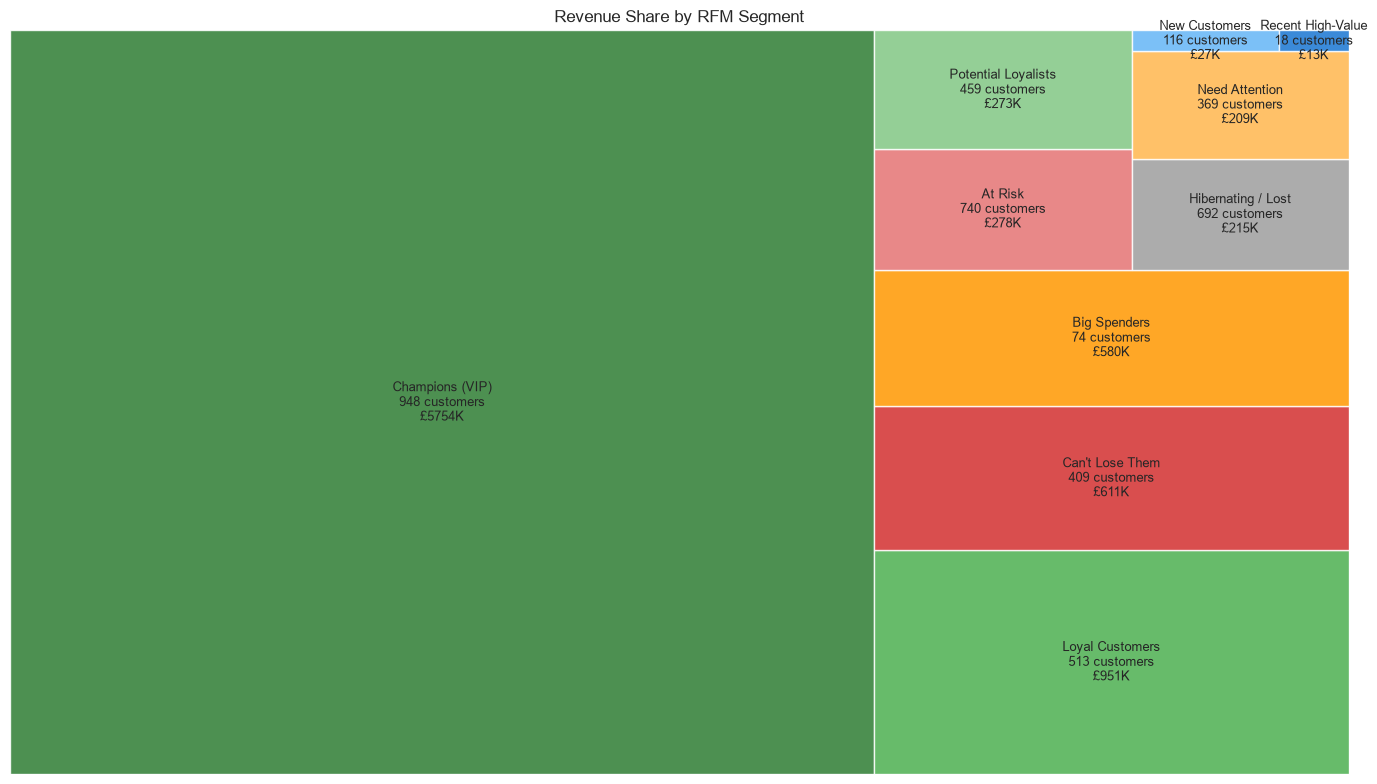

In [9]:
colors = {
    'Champions (VIP)': '#2E7D32', 'Loyal Customers': '#4CAF50',
    'Potential Loyalists': '#81C784', 'Big Spenders': '#FF9800',
    'Need Attention': '#FFB74D', "Can't Lose Them": '#D32F2F',
    'At Risk': '#E57373', 'Hibernating / Lost': '#9E9E9E',
    'New Customers': '#64B5F6', 'Recent High-Value': '#1976D2',
}

df_seg = segment_summary.reset_index()
labels = [f'{r.Segment}\n{r.Customer_Count} customers\n£{r.Total_Monetary / 1e3:.0f}K'
          for r in df_seg.itertuples()]

plt.figure(figsize=(14, 8))
squarify.plot(sizes=df_seg['Total_Monetary'], label=labels,
              color=df_seg['Segment'].map(colors), alpha=0.85, text_kwargs={'fontsize': 9})
plt.title('Revenue Share by RFM Segment')
plt.axis('off')
save('02_rfm_treemap')

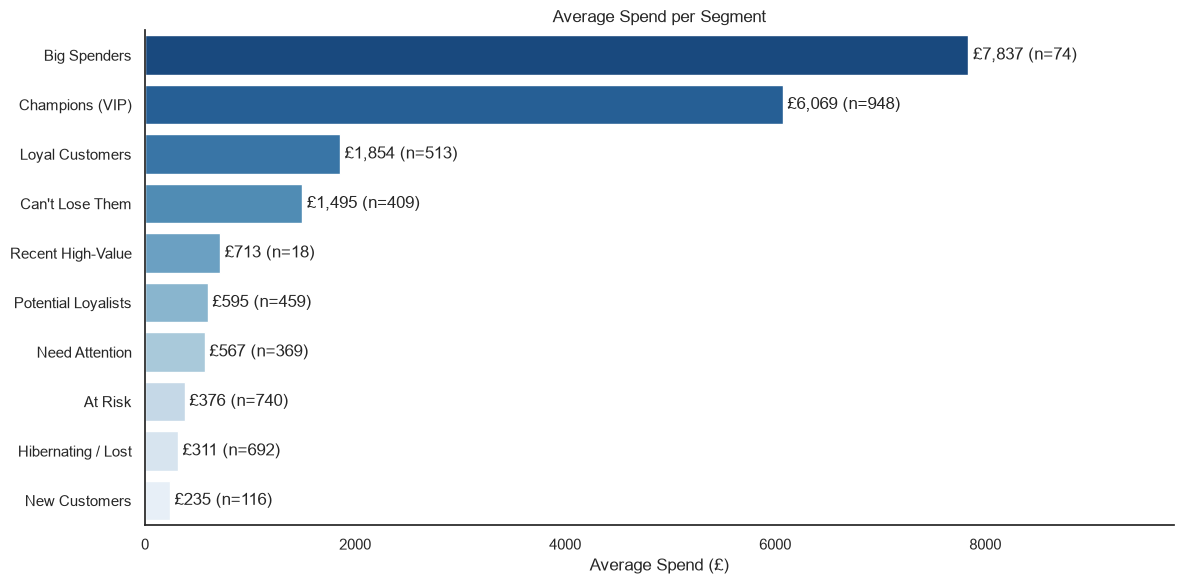

In [10]:
df_avg = df_seg.sort_values('Avg_Monetary', ascending=False)
labels = [f'£{r.Avg_Monetary:,.0f} (n={r.Customer_Count})' for r in df_avg.itertuples()]

barh(df_avg, 'Avg_Monetary', 'Segment', 'Average Spend per Segment',
     'Average Spend (£)', 'Blues_r', '03_segment_avg_monetary', labels=labels, size=(12, 6))

## 5. Churn

A customer is churned if inactive for more than 90 days.

In [11]:
df_churn = run('''
WITH customer_summary AS (
    SELECT
        CustomerID,
        CAST(
            (SELECT julianday(MAX(InvoiceDate)) FROM clean_retail WHERE IsCancelled = 0)
            - julianday(MAX(InvoiceDate)) AS INT
        ) AS recency_days,
        ROUND(SUM(Quantity * UnitPrice), 2) AS total_spend
    FROM clean_retail
    WHERE IsCancelled = 0 AND CustomerID IS NOT NULL
    GROUP BY CustomerID
),
churn_flagged AS (
    SELECT
        CustomerID,
        total_spend,
        CASE WHEN recency_days > 90 THEN 1 ELSE 0 END AS is_churn
    FROM customer_summary
)
SELECT
    COUNT(DISTINCT CustomerID) AS total_customers,
    SUM(is_churn) AS churned_customers,
    COUNT(DISTINCT CustomerID) - SUM(is_churn) AS active_customers,
    ROUND(100.0 * SUM(is_churn) / COUNT(DISTINCT CustomerID), 2) AS churn_rate_pct,
    ROUND(SUM(CASE WHEN is_churn = 1 THEN total_spend ELSE 0 END), 2) AS revenue_at_risk,
    ROUND(SUM(total_spend), 2) AS total_revenue
FROM churn_flagged;
''')
df_churn

,total_customers,churned_customers,active_customers,churn_rate_pct,revenue_at_risk,total_revenue
0,4338,1445,2893,33.31,1033364.08,8911407.9


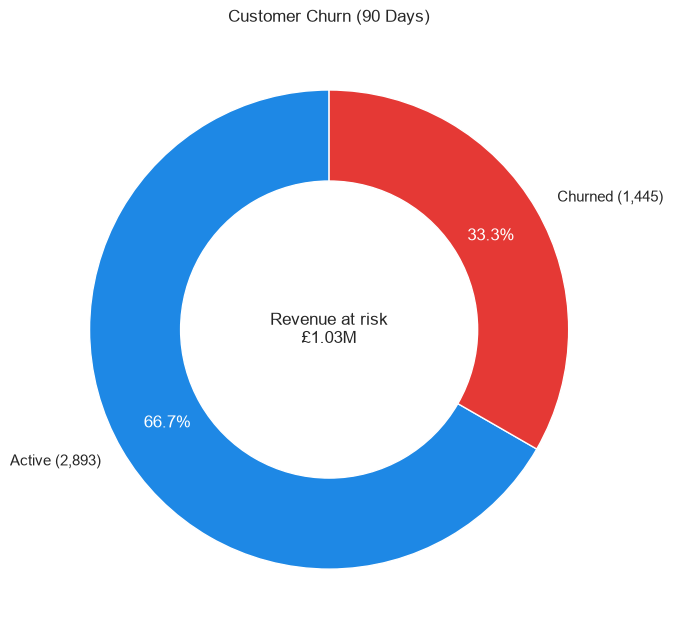

In [12]:
row = df_churn.iloc[0]

plt.figure(figsize=(7, 7))
_, _, pct_labels = plt.pie(
    [row['active_customers'], row['churned_customers']],
    labels=[f"Active ({int(row['active_customers']):,})", f"Churned ({int(row['churned_customers']):,})"],
    colors=['#1E88E5', '#E53935'], autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops={'width': 0.38, 'edgecolor': 'white'},
)
for t in pct_labels:
    t.set_color('white')
plt.text(0, 0, f"Revenue at risk\n£{row['revenue_at_risk'] / 1e6:.2f}M", ha='center', va='center')
plt.title('Customer Churn (90 Days)')
save('04_churn_revenue_risk')

In [13]:
df_rfm.to_sql('rfm_segments', conn, if_exists='replace', index=False)

df_churn_seg = run('''
SELECT
    Segment,
    COUNT(DISTINCT CustomerID) AS total_customers,
    SUM(CASE WHEN recency > 90 THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN recency > 90 THEN 1 ELSE 0 END) / COUNT(DISTINCT CustomerID), 2) AS churn_rate_pct,
    ROUND(SUM(CASE WHEN recency > 90 THEN monetary ELSE 0 END), 2) AS revenue_at_risk,
    ROUND(SUM(monetary), 2) AS total_revenue
FROM rfm_segments
GROUP BY Segment
ORDER BY revenue_at_risk DESC;
''')
df_churn_seg

,Segment,total_customers,churned_customers,churn_rate_pct,revenue_at_risk,total_revenue
0,Can't Lose Them,409,306,74.82,431284.44,611450.98
1,Big Spenders,74,26,35.14,238825.41,579966.73
2,At Risk,740,646,87.30,235795.39,278027.68
3,Hibernating / Lost,692,471,68.06,129365.17,215096.41
4,Recent High-Value,18,0,0.00,0.00,12827.01
5,Potential Loyalists,459,0,0.00,0.00,272972.05
6,New Customers,116,0,0.00,0.00,27208.08
7,Need Attention,369,0,0.00,0.00,209054.03
8,Loyal Customers,513,0,0.00,0.00,951097.50
9,Champions (VIP),948,0,0.00,0.00,5753707.43


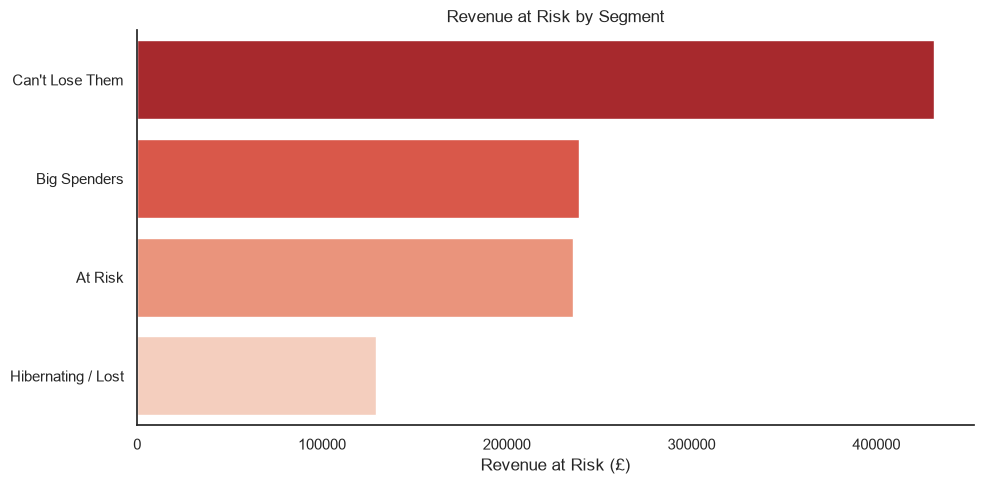

In [14]:
df_risk = df_churn_seg[df_churn_seg['revenue_at_risk'] > 0]

barh(df_risk, 'revenue_at_risk', 'Segment', 'Revenue at Risk by Segment',
     'Revenue at Risk (£)', 'Reds_r', '05_revenue_at_risk_by_segment')

## 6. Cohort Retention

Customers are grouped by first purchase month and tracked over the following months.

In [15]:
df_cohort = run('''
WITH customer_cohort AS (
    SELECT
        CustomerID,
        MIN(STRFTIME('%Y-%m-01', InvoiceDate)) AS cohort_month
    FROM clean_retail
    GROUP BY CustomerID
),
cohort_base AS (
    SELECT DISTINCT
        c.CustomerID,
        cc.cohort_month,
        (STRFTIME('%Y', c.InvoiceDate) - STRFTIME('%Y', cc.cohort_month)) * 12
        + (STRFTIME('%m', c.InvoiceDate) - STRFTIME('%m', cc.cohort_month)) AS cohort_index
    FROM clean_retail c
    JOIN customer_cohort cc ON c.CustomerID = cc.CustomerID
)
SELECT
    cohort_month,
    cohort_index,
    COUNT(DISTINCT CustomerID) AS customer_count
FROM cohort_base
GROUP BY cohort_month, cohort_index
ORDER BY cohort_month, cohort_index;
''')
df_cohort.head()

,cohort_month,cohort_index,customer_count
0,2010-12-01,0,948
1,2010-12-01,1,362
2,2010-12-01,2,317
3,2010-12-01,3,367
4,2010-12-01,4,341


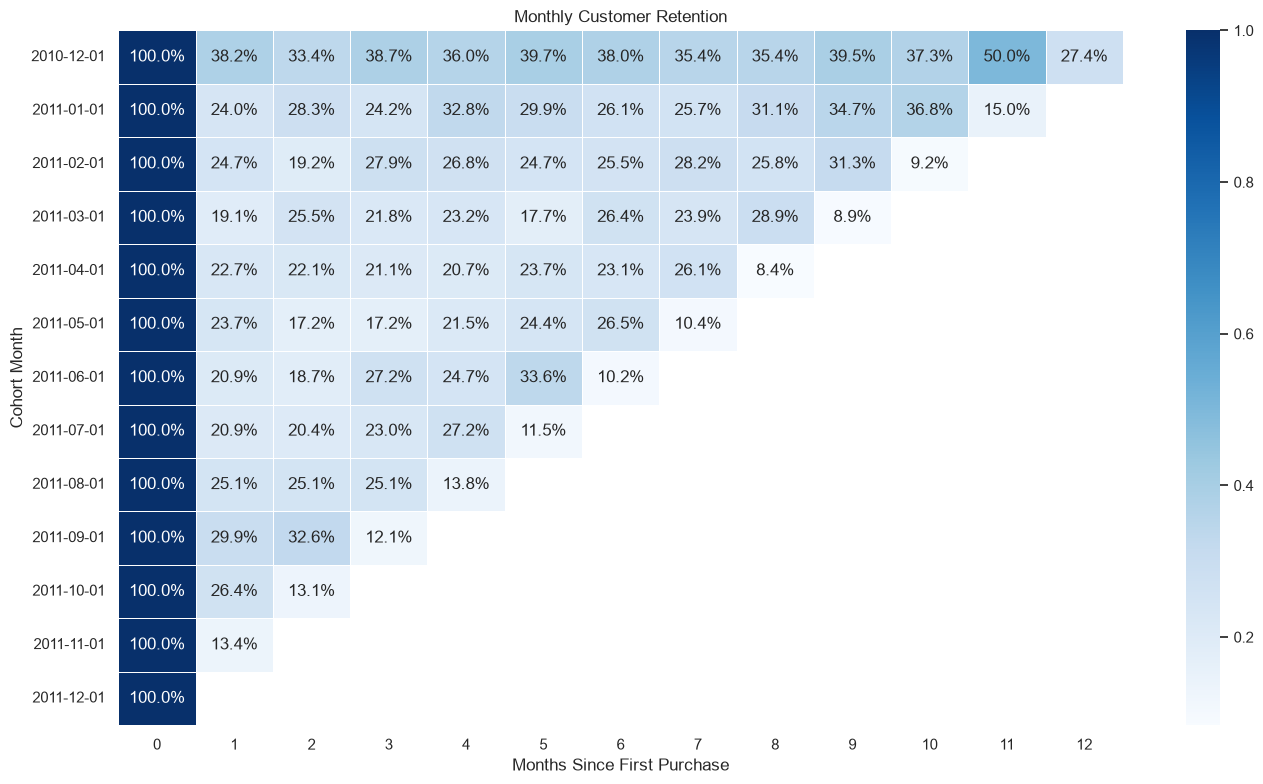

In [16]:
cohort_matrix = df_cohort.pivot(index='cohort_month', columns='cohort_index', values='customer_count')
retention = cohort_matrix.divide(cohort_matrix.iloc[:, 0], axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.1%', cmap='Blues', linewidths=0.5)
plt.title('Monthly Customer Retention')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
save('06_cohort_retention_heatmap')

## 7. Customer Lifetime Value (CLV)

Simple CLV per segment: average customer value x average lifespan in months (minimum 1 month).

In [17]:
df_clv = run('''
WITH customer_base AS (
    SELECT
        CustomerID,
        ROUND(SUM(TotalAmount), 2) AS total_spend,
        COUNT(DISTINCT InvoiceNo) AS total_orders,
        SUM(TotalAmount) / COUNT(DISTINCT InvoiceNo) AS avg_order_value,
        1.0 * COUNT(DISTINCT InvoiceNo) / (
            SELECT COUNT(DISTINCT CustomerID)
            FROM clean_retail
            WHERE IsCancelled = 0 AND CustomerID IS NOT NULL
        ) AS purchase_frequency,
        ROUND(julianday(MAX(InvoiceDate)) - julianday(MIN(InvoiceDate)), 1) AS lifespan_days
    FROM clean_retail
    WHERE IsCancelled = 0 AND CustomerID IS NOT NULL
    GROUP BY CustomerID
)
SELECT
    CustomerID,
    total_spend,
    total_orders,
    avg_order_value,
    purchase_frequency,
    avg_order_value * purchase_frequency AS customer_value,
    lifespan_days
FROM customer_base;
''')

df_clv = df_clv.merge(df_rfm[['CustomerID', 'Segment']], on='CustomerID')

clv_segments = df_clv.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_AOV=('avg_order_value', 'mean'),
    Avg_Customer_Value=('customer_value', 'mean'),
    Avg_Lifespan_Days=('lifespan_days', 'mean'),
    Total_Spend=('total_spend', 'sum'),
).reset_index()

months = (clv_segments['Avg_Lifespan_Days'] / 30).clip(lower=1)
clv_segments['Estimated_CLV'] = clv_segments['Avg_Customer_Value'] * months
clv_segments['Projected_Revenue'] = clv_segments['Estimated_CLV'] * clv_segments['Customer_Count']
clv_segments = clv_segments.sort_values('Projected_Revenue', ascending=False)
clv_segments

,Segment,Customer_Count,Avg_AOV,Avg_Customer_Value,Avg_Lifespan_Days,Total_Spend,Estimated_CLV,Projected_Revenue
3,Champions (VIP),948,466.520662,1.399104,280.717300,5753707.43,13.091753,12410.982114
5,Loyal Customers,513,317.521977,0.427384,226.258480,951097.50,3.223307,1653.556742
2,Can't Lose Them,409,488.935525,0.344627,137.538386,611450.98,1.579980,646.211627
1,Big Spenders,74,4288.113971,1.806682,122.181081,579966.73,7.358080,544.497942
8,Potential Loyalists,459,297.430290,0.137093,111.413072,272972.05,0.509133,233.691829
6,Need Attention,369,322.140447,0.130600,90.878591,209054.03,0.395624,145.985367
0,At Risk,740,250.508256,0.086610,47.476351,278027.68,0.137064,101.427232
4,Hibernating / Lost,692,310.832962,0.071654,0.000000,215096.41,0.071654,49.584235
7,New Customers,116,234.552414,0.054069,0.000000,27208.08,0.054069,6.272033
9,Recent High-Value,18,712.611667,0.164272,0.000000,12827.01,0.164272,2.956895


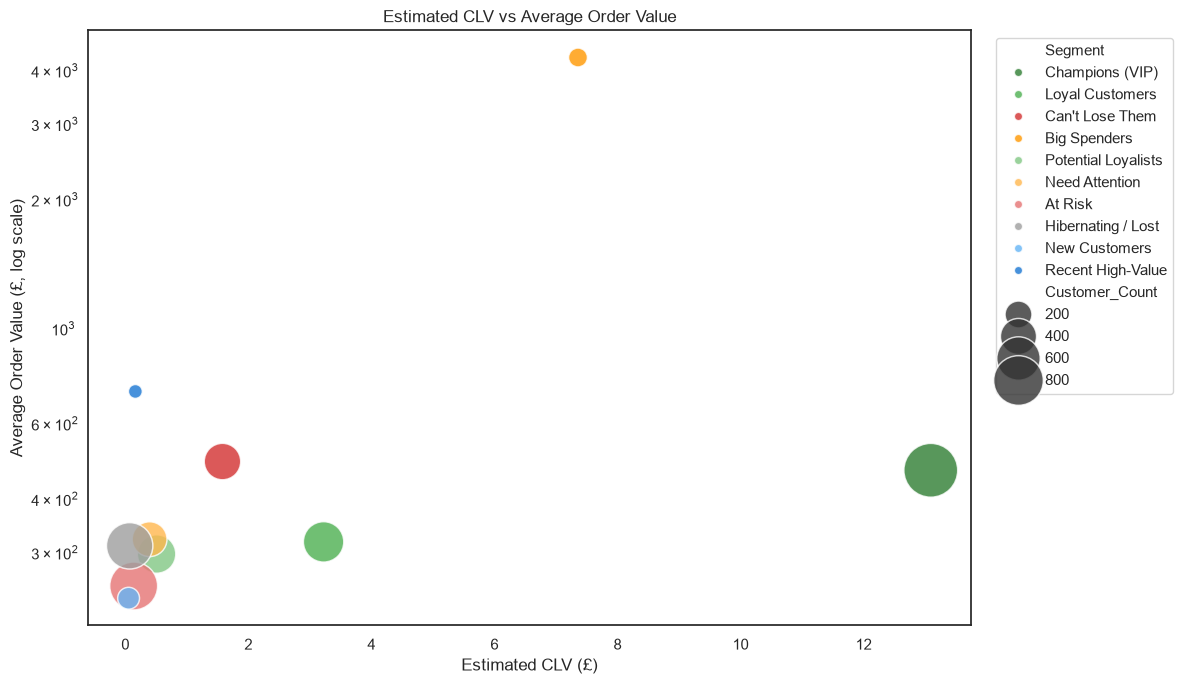

In [18]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=clv_segments, x='Estimated_CLV', y='Avg_AOV', size='Customer_Count',
                sizes=(100, 1500), hue='Segment', palette=colors, alpha=0.8)
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('Estimated CLV vs Average Order Value')
plt.xlabel('Estimated CLV (£)')
plt.ylabel('Average Order Value (£, log scale)')
save('07_segment_clv_vs_aov')

## 8. Market Basket

Top 20 product pairs that appear together in the same invoice.

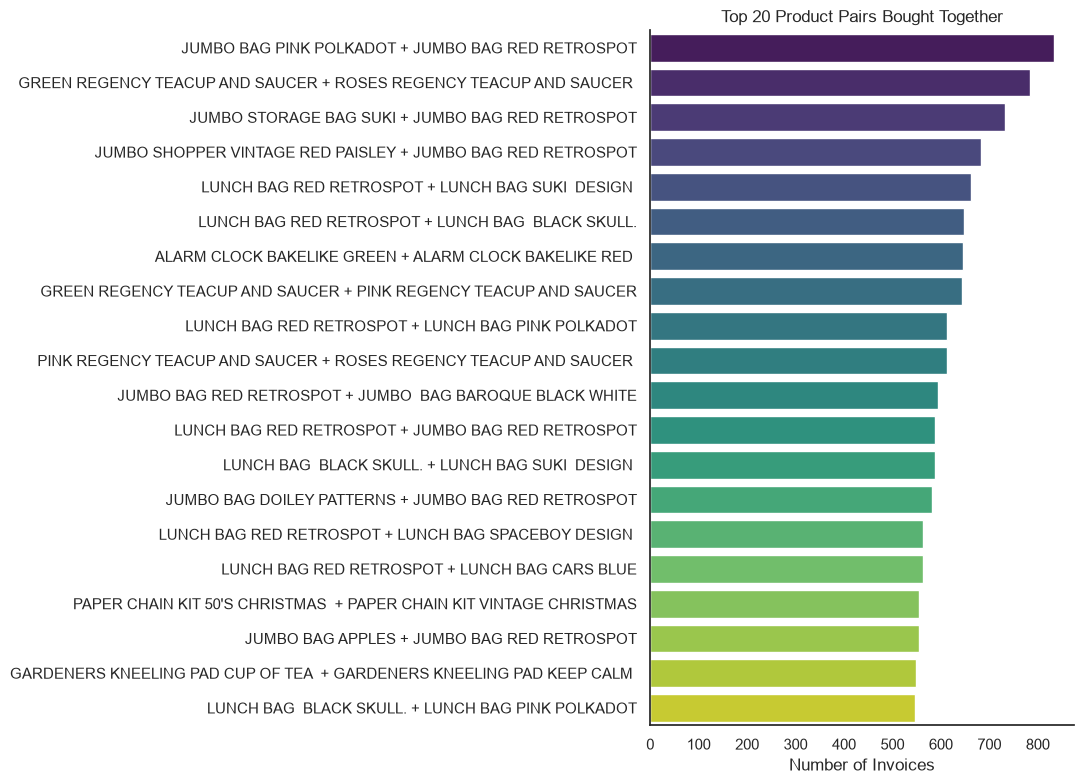

In [19]:
df_pairs = run('''
WITH invoice_items AS (
    SELECT DISTINCT InvoiceNo, StockCode, Description
    FROM clean_retail
    WHERE Description IS NOT NULL
)
SELECT
    a.Description AS product_a,
    b.Description AS product_b,
    COUNT(*) AS pair_frequency
FROM invoice_items a
JOIN invoice_items b
    ON a.InvoiceNo = b.InvoiceNo AND a.StockCode < b.StockCode
GROUP BY a.StockCode, b.StockCode
ORDER BY pair_frequency DESC
LIMIT 20;
''')

df_pairs['product_pair'] = df_pairs['product_a'] + ' + ' + df_pairs['product_b']

barh(df_pairs, 'pair_frequency', 'product_pair', 'Top 20 Product Pairs Bought Together',
     'Number of Invoices', 'viridis', '08_market_basket_top20', size=(11, 8))